### INTRODUCTION

This notebook aims at comparing two different Building FootPrint datasets (OSM and GBA) for any choosen area of interest , to determine use case specific advantages and limitations. 

Baseline Code Source: 
https://milanjanosov.substack.com/p/openstreetmap-vs-global-building?r=3o5qdz&utm_campaign=post&utm_medium=web&triedRedirect=true

### Note
Accuracy note: GBA's height model was trained on only 168 city scale regions worldwide, heavily skewed toward Europe (109 cities) and North America (39), with just 2 cities in Asia, 1 in South America, and none in Africa. Height accuracy: RMSE (Root mean Square error) ranges from 1.5m (Oceania) to 8.9m (South America), and predictions in Africa are unvalidated. Treat results there with extra caution.

GBA.Polygon is a fusion of OSM, Google Open Buildings, Microsoft, and CLSM footprints, so completeness and precision vary by region depending on which source dominates locally. Performance is weakest in South America (lowest precision/recall of all continents) and untested against ground truth in Africa. Footprint counts and shapes there should be treated as indicative, not authoritative.


### Import Packages

In [1]:
%pip install osmnx 
%pip install folium
%pip install matplotlib
%pip install --upgrade certifi
%pip install pyarrow


import osmnx as ox 
import math 
import geopandas as gpd 
import urllib.request
import urllib.error
import math 
import pandas as pd 
from shapely import wkb 
from shapely.geometry import box 
import folium 
from folium.plugins import GroupedLayerControl 
import json
import warnings
import time
import ssl
import certifi
import os

warnings.filterwarnings('ignore')

  Using cached geopandas-1.1.4-py3-none-any.whl.metadata (2.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached numpy-2.5.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached shapely-2.1.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached pyogrio-0.13.0-cp311-abi3-macosx_12_0_arm64.whl.metadata (5.8 kB)
  Using cached pyproj-3.7.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (31 kB)
Using cached geopandas-1.1.4-py3-none-any.whl (343 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached numpy-2.5.1-cp314-cp314-macosx_14_0_arm64.whl (5.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 26.5 MB/s  0:00:00eta 0:00:01
Using cached pyogrio-0.13.0-cp311-abi3-macosx_12_0_arm64.whl (24.7 MB)
Using cached pyproj-3.7.2-cp314-cp314-macosx_14_0_arm64.whl (4.6 MB)
Using cached shapely-2.1.2-cp314-cp314-macosx_11_0_arm64.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [osmnx]32m6/8 [geopandas]
N

### 1. Add OSM Buildings

In this block, the user defines the area of interest by either adding a shapefile of coordinates. The cell then creates a bounding box for the area of interest with a buffer of ~5km.

user input required
User decides mode for defining the AOI by selection 1 (Input coordinates) or 2(Input Shapefile path) 
NOTE:
All .shp accompanied files .shx,.dbf , .prj are is same folder when selecting shapefile path

Expected Output:
A plot of the area on interest with OSM buildings and the polygon features count (number of buildings)


153530


<Axes: >

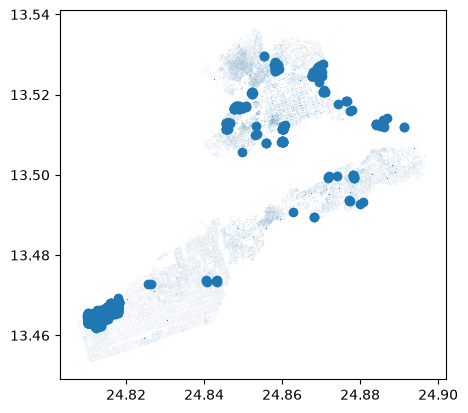

In [2]:
def get_aoi_from_shapefile(shapefile_path):
    aoi_gdf = gpd.read_file(shapefile_path)
    if aoi_gdf.crs is None:
        raise ValueError("Shapefile has no CRS defined — cannot safely reproject. Check the .prj file.")
    aoi_gdf = aoi_gdf.to_crs("EPSG:4326")
    geom = aoi_gdf.geometry.union_all()
    return geom
    
mode= input ("Define AOI by (1) coordinates or (2) Shapefile? Enter 1 or 2: ").strip()

if mode=="1": 
    lat= float(input("enter latitude:").strip())
    lon= float(input("enter longitude:").strip())
    buffer = 0.05  # ~5km
    geom = box(lon - buffer, lat - buffer, lon + buffer, lat + buffer)
    
elif mode=="2":
    shapefile_path=input ("Enter path to the .shp file:").strip().strip('"\'')
    geom=get_aoi_from_shapefile(shapefile_path)

else:
    raise ValueError("Invalid choice-enter 1or 2.")


buildings_osm = ox.features_from_polygon(geom, tags={'building': True})
print(len(buildings_osm))
buildings_osm.plot()

### 2. Add Global Buildings Atlas Data

Source: 
https://github.com/zhu-xlab/GlobalBuildingAtlas

Mirror Source:
https://source.coop/tge-labs/globalbuildingatlas-lod1

The GBA Datasets are stored in 5°x 5° tiles and this block aims at gettings the tile intersectiong with the bounding boxes in WGS84. 
This will return all GBA tile names that intersect the defined AOI. This will work for any geometry type(point,polygon,multipolygon, e.t.c.)




In [3]:
def get_tiles_from_geometry(geom):
    
    minx, miny, maxx, maxy = geom.bounds

    # Find all 5° tiles that overlap the bounding box
    lon_start = math.floor(minx / 5) * 5
    lat_start = math.floor(miny / 5) * 5

    tiles = []
    lon = lon_start
    while lon < maxx:
        lat = lat_start
        while lat < maxy:
            lon_min = lon
            lon_max = lon + 5
            lat_min = lat
            lat_max = lat + 5

            ew_min = 'e' if lon_min >= 0 else 'w'
            ew_max = 'e' if lon_max >= 0 else 'w'
            ns_max = 'n' if lat_max >= 0 else 's'
            ns_min = 'n' if lat_min >= 0 else 's'

            tile = (
                f"{ew_min}{abs(lon_min):03d}_{ns_max}{abs(lat_max):02d}"
                f"_{ew_max}{abs(lon_max):03d}_{ns_min}{abs(lat_min):02d}.parquet"
            )
            tiles.append(tile)
            lat += 5
        lon += 5

    return tiles



tiles = get_tiles_from_geometry(geom)
print(tiles)

['e020_n15_e025_n10.parquet']


### 2.1 Downloads tile from the mirror source. 

Expected User input: File location for saving the tile and yes/no to file download after 


In [4]:
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; research-script/1.0)"}
SSL_CTX = ssl.create_default_context(cafile=certifi.where())

def download_gba_tile(tile_name, save_dir, max_retries=4, timeout=15):
    url = f"https://data.source.coop/tge-labs/globalbuildingatlas-lod1/{tile_name}"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, tile_name)

    if os.path.exists(save_path):
        print(f"{tile_name} already exists locally — skipping download.")
        return save_path

    #Checks how big the file is and if the server exist and is readable
    for attempt in range(1, max_retries + 1):
        try:
            req = urllib.request.Request(url, headers={**HEADERS, "Range": "bytes=0-0"})
            with urllib.request.urlopen(req, context=SSL_CTX, timeout=timeout) as r:
                size_bytes = int(r.headers.get("Content-Range", "0/0").split("/")[-1])
                print(f"{tile_name} size: {size_bytes/1024**3:.2f} GB")
            break
        except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
            print(f"Attempt {attempt} failed: {e}")
            if attempt < max_retries:
                wait = 2 ** attempt
                print(f"Retrying in {wait}s...")
                time.sleep(wait)
            else:
                print("Giving up after max retries.")
                return None
    else:
        return None

    print(f"Will save to: {save_path}")
    confirm = input(f"Proceed downloading {tile_name}? (y/n): ")
    if confirm.lower() != "y":
        print("Cancelled.")
        return None

    req = urllib.request.Request(url, headers=HEADERS)
    with urllib.request.urlopen(req, context=SSL_CTX, timeout=timeout) as response, open(save_path, "wb") as out_file:
        out_file.write(response.read())
    print(f"Saved: {save_path}")
    return save_path


# ask ONCE for the save folder, reused for both tiles
save_dir = input("Where should the tiles be saved? (enter folder path): ").strip().strip('"\'')

tile_paths = []
for t in tiles:
    tile_path = download_gba_tile(t, save_dir)
    if tile_path is None:
        raise RuntimeError(f"Download failed or was cancelled for {t}.")
    tile_paths.append(tile_path)

print(f"Downloaded {len(tile_paths)} tile(s): {tile_paths}")

gdf = gpd.read_parquet(tile_paths[0])
gdf.head(3)

e020_n15_e025_n10.parquet already exists locally — skipping download.
Downloaded 1 tile(s): ['/Users/chippomchenga/Documents/Summer Internship_CDL /Datasets/e020_n15_e025_n10.parquet']


,source,id,height,var,region,bbox,geometry
0,google,7G46FXWC+FG54,1.660938,0.636230,SDN,"{'xmin': 24.9713278387173, 'ymin': 12.49609599...","POLYGON ((24.97139 12.49611, 24.97138 12.49616..."
1,google,7G46FXVF+MF6C,0.682637,0.172652,SDN,"{'xmin': 24.9736033950638, 'ymin': 12.49414279...","POLYGON ((24.97365 12.49418, 24.9736 12.49418,..."
2,google,7G46FXWF+49P8,0.652470,0.062614,SDN,"{'xmin': 24.9734196457198, 'ymin': 12.49530465...","POLYGON ((24.97349 12.49534, 24.97344 12.49536..."


### 2.2 converts each row's bytes into an actual Shapely geometry object

Combined 1 tile(s) — total rows: 4134960
OGC:CRS84
   source             id    height       var region  \
0  google  7G46FXWC+FG54  1.660938  0.636230    SDN   
1  google  7G46FXVF+MF6C  0.682637  0.172652    SDN   
2  google  7G46FXWF+49P8  0.652470  0.062614    SDN   
3  google  7G46FXWF+4922  0.934944  0.135695    SDN   
4  google  7G46FXWF+3C8X  1.147444  0.234350    SDN   

                                                bbox  \
0  {'xmin': 24.9713278387173, 'ymin': 12.49609599...   
1  {'xmin': 24.9736033950638, 'ymin': 12.49414279...   
2  {'xmin': 24.9734196457198, 'ymin': 12.49530465...   
3  {'xmin': 24.973354292703203, 'ymin': 12.495229...   
4  {'xmin': 24.9735642634709, 'ymin': 12.49514536...   

                                            geometry  
0  POLYGON ((24.97139 12.49611, 24.97138 12.49616...  
1  POLYGON ((24.97365 12.49418, 24.9736 12.49418,...  
2  POLYGON ((24.97349 12.49534, 24.97344 12.49536...  
3  POLYGON ((24.9734 12.49524, 24.97338 12.49528,...  
4  POL

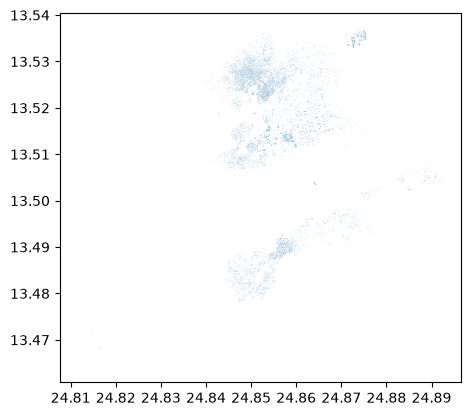

In [5]:

# load and combine all downloaded tiles
gdfs = [gpd.read_parquet(p) for p in tile_paths]
gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)
print(f"Combined {len(gdfs)} tile(s) — total rows: {len(gdf)}")
print(gdf.crs)  # confirm what CRS it actually is, rather than assuming 4326
print(gdf.head())

buildings_gba = gdf[gdf.geometry.intersects(geom)]
print(f"Buildings intersecting AOI: {len(buildings_gba)}")
buildings_gba.plot()

save_geojson = input("Save the AOI buildings as Geojson? (y/n):").strip().lower()
if save_geojson == "y":
    aoi_geojson_path = os.path.join(save_dir, "buildings_gba_aoi.geojson")
    buildings_gba.to_file(aoi_geojson_path, driver="GeoJSON")
    print(f"Saved AOI-filtered buildings as: {aoi_geojson_path}")


### Tile Boundary Duplication Check
Run the below cells if the AOI falls between two tiles.
 
GBA is distributed don't specify how buildings sitting exactly on a tile edge are handled. If our AOI spans two tiles, that same building could be double-counted (two IDs), safely duplicated (same ID, identical geometry — easy to deduplicate), or split (same ID, different/clipped geometry — needs merging before measuring area/volume). This section checks which case applies, since it directly affects the accuracy of any building count or volume total near a tile edge. 

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, edgecolor="black", alpha=0.5)
# draw the tile boundary line for reference
boundary_lon = bounds_list[0][2]  # adjust based on which edge is shared
ax.axvline(boundary_lon, color="red", linestyle="--", label="Tile boundary")
ax.legend()
plt.title("Buildings near tile boundary — check for split/duplicate polygons visually")
plt.show()

In [ ]:
# --- Investigate whether buildings crossing the tile edge are split or duplicated ---

# 1. Only meaningful if you have more than one tile
if len(gdfs) < 2:
    print("Only one tile was loaded — no tile boundary exists to test.")
else:
    # get the boundary line between the two tiles (works for a simple 2-tile case)
    # this assumes the tiles are adjacent either east-west or north-south
    bounds_list = [g.total_bounds for g in gdfs]  # [minx, miny, maxx, maxy] per tile
    print("Tile bounds:")
    for i, b in enumerate(bounds_list):
        print(f"  Tile {i}: {b}")

    # find duplicate IDs across the combined dataset — same ID appearing in >1 tile
    dupe_mask = gdf["id"].duplicated(keep=False)
    dupes = gdf[dupe_mask].sort_values("id")

    print(f"\nBuildings with duplicate IDs across tiles: {dupes['id'].nunique()}")

    if len(dupes) > 0:
        print("\nSample of duplicated buildings:")
        print(dupes[["id", "source", "height"]].head(10))

        # check whether the geometry is identical or different (clipped) for a duplicate ID
        sample_id = dupes["id"].iloc[0]
        matches = gdf[gdf["id"] == sample_id]
        print(f"\nInspecting id={sample_id} — found in {len(matches)} rows")
        for idx, row in matches.iterrows():
            print(f"  Area: {row.geometry.area:.8f} | Bounds: {row.geometry.bounds}")

        geom_a = matches.geometry.iloc[0]
        geom_b = matches.geometry.iloc[1]
        print(f"\nGeometry identical across tiles? {geom_a.equals(geom_b)}")
    else:
        print("No duplicate IDs found — either buildings near the boundary got unique IDs per tile (split/counted separately), or no building happens to straddle the exact line in this AOI.")

In [ ]:
# recreate bounds_list from your loaded tile GeoDataFrames
bounds_list = [g.total_bounds for g in gdfs]
print("Tile bounds:", bounds_list)

boundary_lon = bounds_list[0][2]  # east edge of the first tile
zoom_buffer = 0.05

near_boundary = gdf.cx[boundary_lon - zoom_buffer : boundary_lon + zoom_buffer, :]
print(f"Buildings near boundary: {len(near_boundary)}")

fig, ax = plt.subplots(figsize=(10, 10))
near_boundary.plot(ax=ax, edgecolor="black", alpha=0.5)
ax.axvline(boundary_lon, color="red", linestyle="--", label="Tile boundary")
ax.legend()
plt.title("Buildings near tile boundary")
plt.show()


### 3. Datasets comparison

### 3.1 Area Comparison

The area comparison helps us understand how much phusical space are the buildings occupying.
If GBA's footprint area is close to OSM's in a well-mapped area, that's a good sign the fusion process preserved building shapes reasonably well relative to what's on the ground.

If GBA is significantly larger than OSM, it may indicate GBA is capturing buildings OSM missed entirely (a completeness gain — the core selling point of GBA), or it could reflect merged/over-generalized polygons inflating area.

If GBA is significantly smaller than OSM, like thecase for Tawila, south Sudan, this indicate GBA missing structures since there was a specialised OSM community mapping of the area.

In [6]:
print("OSM buildings:", len(buildings_osm))
print("GBA buildings:", len(buildings_gba))

osm_total_area = buildings_osm.to_crs("EPSG:3857").geometry.area.sum()
gba_total_area = buildings_gba.to_crs("EPSG:3857").geometry.area.sum()

print(f"OSM total footprint: {osm_total_area/1e6:.4f} km²")
print(f"GBA total footprint: {gba_total_area/1e6:.4f} km²")
print(f"GBA covers {100*gba_total_area/osm_total_area:.1f}% of OSM footprint area")

OSM buildings: 153530
GBA buildings: 23763
OSM total footprint: 1.3398 km²
GBA total footprint: 0.4823 km²
GBA covers 36.0% of OSM footprint area


### 3.2 Number of Building Comparison
Since the building polygons have differnt sources, first we count the number of building to their corresponding sources.
ms    = Microsoft
goo   = Google Open Buildings
osm   = OpenStreetMap
ours2 = TUM satellite-derived

Then we compare in percentages the number of buildings with hieght. This is to highligh the clear advantages of TUM GBA dataset over OSM.


In [7]:
print(buildings_gba["source"].value_counts())

# OSM typically stores height as a string tag — convert first
buildings_osm["height_m"] = pd.to_numeric(buildings_osm.get("height"), errors="coerce")

# GBA height is already numeric
buildings_gba["height_m"] = pd.to_numeric(buildings_gba["height"], errors="coerce")


# Compare
osm_with_height = buildings_osm["height_m"].notna().sum()
gba_with_height = buildings_gba["height_m"].notna() & (buildings_gba["height_m"] > 0)
gba_with_height = gba_with_height.sum()

print(f"OSM buildings with height: {osm_with_height} / {len(buildings_osm)} ({100*osm_with_height/len(buildings_osm):.1f}%)")
print(f"GBA buildings with height: {gba_with_height} / {len(buildings_gba)} ({100*gba_with_height/len(buildings_gba):.1f}%)")

source
google    23755
osm           8
Name: count, dtype: int64
OSM buildings with height: 0 / 153530 (0.0%)
GBA buildings with height: 23763 / 23763 (100.0%)


### 4. Map Visualisation of the Two Datasets

The final map will show the AOI OSM and TUM GBA buildings ovrlayed. The layers can be turned on or off to compare covarage.
With is map. users can take a closer look at the AOI

In [ ]:
# prep
buildings_osm = buildings_osm.to_crs("EPSG:4326")
buildings_gba = buildings_gba.to_crs("EPSG:4326")

# --- keep polygons only, drop points/other geometry types ---
buildings_osm = buildings_osm[buildings_osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
buildings_gba = buildings_gba[buildings_gba.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]

# center
center_point = buildings_gba.to_crs("EPSG:3857").geometry.centroid.to_crs("EPSG:4326")
center = [center_point.y.mean(), center_point.x.mean()]

# map
m = folium.Map(
    location=center,
    zoom_start=18,
    max_zoom=22,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery"
)

# OSM layer — blue with height, grey without
osm_layer = folium.FeatureGroup(name="🔵 OSM Buildings", show=True)
for _, row in buildings_osm.iterrows():
    has_height = pd.notna(row["height_m"]) and row["height_m"] > 0
    color = "#4A90D9" if has_height else "#888888"
    opacity = 0.7 if has_height else 0.2
    tooltip = f"Height: {row['height_m']}m" if has_height else "No height data"
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda x, c=color, o=opacity: {
            "fillColor": c, "color": c, "weight": 1, "fillOpacity": o
        },
        tooltip=tooltip
    ).add_to(osm_layer)
osm_layer.add_to(m)

# GBA layer — orange with height, grey without
gba_layer = folium.FeatureGroup(name="🟠 GBA Buildings", show=True)
for _, row in buildings_gba.iterrows():
    has_height = pd.notna(row["height_m"]) and row["height_m"] > 0
    color = "#E8813A" if has_height else "#888888"
    opacity = 0.7 if has_height else 0.2
    tooltip = f"Height: {row['height_m']}m | Source: {row.get('source', 'N/A')}" if has_height else f"No height | Source: {row.get('source', 'N/A')}"
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda x, c=color, o=opacity: {
            "fillColor": c, "color": c, "weight": 1, "fillOpacity": o
        },
        tooltip=tooltip
    ).add_to(gba_layer)
gba_layer.add_to(m)

# controls + legend
folium.LayerControl(collapsed=False, show_base_layers=False).add_to(m)
m.get_root().html.add_child(folium.Element("""
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
    background:rgba(20,20,20,0.85); padding:12px 18px; border-radius:8px;
    color:white; font-family:monospace; font-size:13px; border:1px solid #444;">
    <b>Height Data Coverage</b><br><br>
    <span style="color:#4A90D9">■</span> OSM — has height<br>
    <span style="color:#E8813A">■</span> GBA — has height<br>
    <span style="color:#888888">■</span> No height data<br><br>
    <span style="font-size:11px; color:#aaa">Toggle layers top-right</span>
</div>
"""))
m
